# Flamapp AI R&D assignment

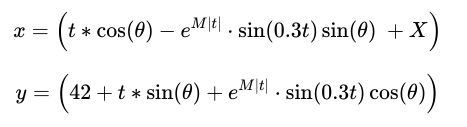

given the above eqs, we can see the unknonws: 

        1. theta determines the rotation angle

        2. M controls the exponential growth(can also be decay)

        3. X is translation/shift

while t varies from 6 to 60 , so there is no much significance in mod|t| i think since t is always +ve.

we are given the data points (x,y) so we can build the actual curve from these points . The goal is to estimate the values of theta , M, X such that newly generated curve closely matches the build curve from data. The metric that determines this closeness quality is L1 distance btw expected and predicted curve.

since the equations are already known, the curve structure must be fixed already, so this problem might not require ML model as such , we can do it using traditional methods itself like non linear parameter estimation.

### Approach -1 

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["font.size"] = 12

df = pd.read_csv("xy_data.csv")
df.head()

,x,y
0,88.364456,57.784378
1,74.283936,54.406780
2,60.256474,46.311462
3,82.134370,57.717567
4,101.036390,67.849340


In [103]:
print(df.shape)
df.describe()

(1500, 2)


,x,y
count,1500.000000,1500.000000
mean,83.713931,58.263519
std,13.697157,7.696524
min,59.657204,46.032295
25%,72.282910,51.124211
50%,84.710995,57.681288
75%,93.368257,66.138374
max,109.231520,69.685510


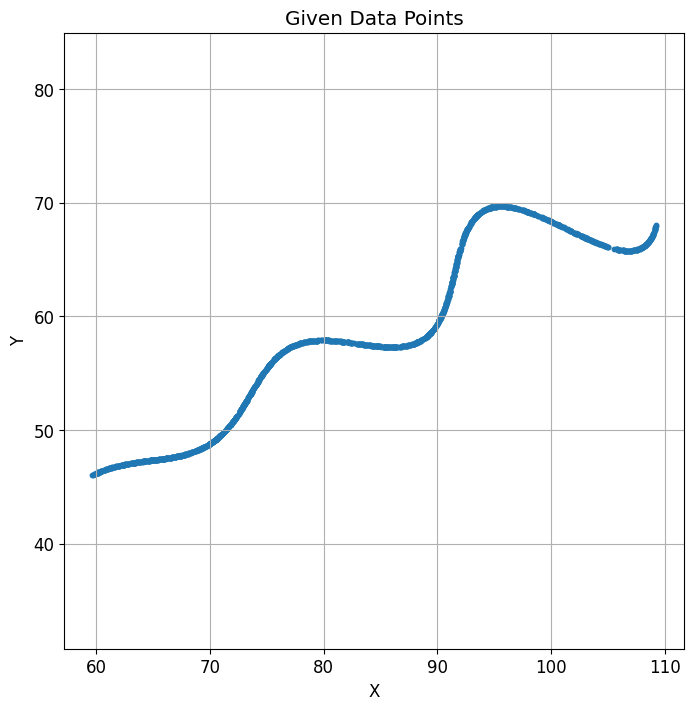

In [104]:
plt.figure(figsize=(8,8))
plt.scatter(df["x"], df["y"], s=10)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Given Data Points")
plt.grid(True)
plt.axis("equal")
plt.show()

we will be leveraging the t to sample points in 6 to 60 and the nearest predited point approximates to the true t . So before we implement this idea lets make a function to generate the new curve

In [105]:
import numpy as np
def generate_curve(theta_deg, M, X, num_points=5000):
    theta = np.deg2rad(theta_deg)
    t = np.linspace(6, 60, num_points)
    x = (t*np.cos(theta)
        - np.exp(M*np.abs(t))*np.sin(0.3*t)*np.sin(theta)
        + X
    )
    y = (42
        + t*np.sin(theta)
        + np.exp(M*np.abs(t))*np.sin(0.3*t)*np.cos(theta)
    )
    return x,y

now lets write a function that will compute the l1 difference of curves. The problem is how to get the nearest points to actual line from predicted line. So to solve this my idea is to use  a KDtree that will make the process more optimized than searching in a simple array. Since KDTree uses binary search approach , it does fetch in log(n) compexity. So we will have nearest points fetched and compared to get L1  

In [106]:
from scipy.spatial import cKDTree

actual_points = df[['x','y']].values

def compute_l1(theta, M, X):
    pred_x, pred_y = generate_curve(theta, M, X)
    pred_points = np.column_stack((pred_x,pred_y))

    tree = cKDTree(pred_points)
    _, idx = tree.query(actual_points)
    nearest = pred_points[idx]
    l1 = np.sum(np.abs(actual_points-nearest))
    return l1

In [107]:
#trail check
theta = 20
M = 0
X = 30
compute_l1(theta,M,X)

14890.282394886694

now lets do parameter estimation method where lets try using differential evolution. since only 3 bounded params are unknowns and gradients are unavailable , differential evolution is suitable global optimizer. It searches the parameter space without requiring derivatives and is less sensitive to local minima than many other classicall methids.

the objective func is non differentiable because it relies on nearest neighbour matching btw predicted and actual curve points. Small changes in paramnetrs will abruptly change the nearest neighbour assignments, making analytical grads unavailable . So i think differential evolution is suitable since its derivative free , supports bounded search spaces, and is effective for low dimensional non linear optimization problems

In [108]:
from scipy.optimize import differential_evolution
import time
bounds = [
    (0,50),
    (-0.05,0.05),
    (0,100)
]


start_time = time.time()
result = differential_evolution(
    lambda p: compute_l1(p[0],p[1],p[2]),
    bounds,
    maxiter=150,
    popsize=20,
    polish=True,
    seed=42
)
end_time = time.time()

approach1_time = end_time - start_time

print(f"Execution Time : {approach1_time:.3f} seconds")
approach1_l1 = result.fun

Execution Time : 5.790 seconds


In [109]:
theta_best, M_best, X_best = result.x

print(f"Theta : {theta_best:.5f}")
print(f"M     : {M_best:.6f}")
print(f"X     : {X_best:.5f}")

print(f"\nBest L1 : {result.fun:.6f}")

Theta : 29.99999
M     : 0.030000
X     : 54.99980

Best L1 : 6.111363


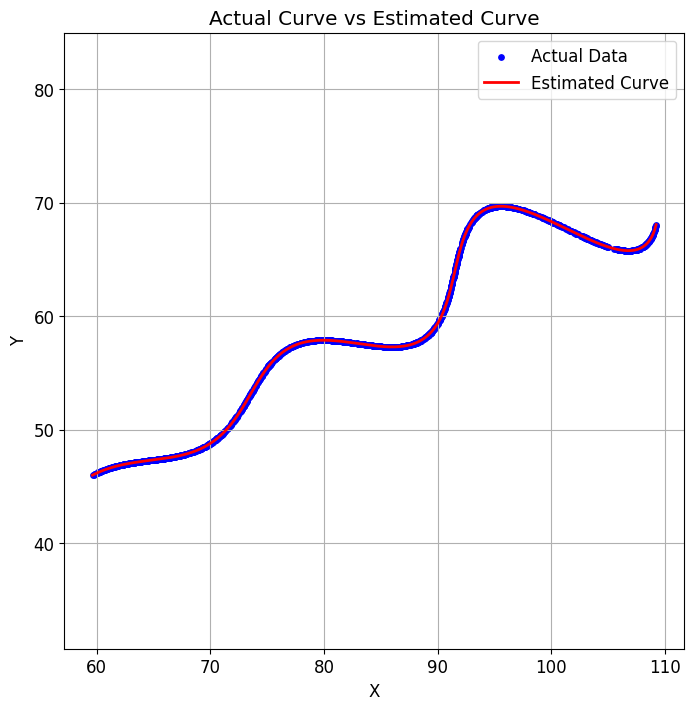

In [ ]:
pred_x, pred_y = generate_curve(theta_best, M_best, X_best)

plt.figure(figsize=(8,8))
plt.scatter(
    df["x"],
    df["y"],
    s=15,
    color="blue",
    label="Actual Data"
)
plt.plot(
    pred_x,
    pred_y,
    color="red",
    linewidth=2,
    label="Estimated Curve"
)
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.title("Actual Curve vs Estimated Curve")

plt.xlabel("X")
plt.ylabel("Y")

plt.show()

Initially i considered whether this could be solved using supervised ML, but here we are given only single observed curve while desired ouputs theta , X,M are unknowns, since there are no labeled examples availabe , i thought may be we can generate random points and make a curve and then compare to get L1 score with original curve ,but problem is how to have gradients and how to update the curve to fit it and get optimal unknowns. So i came up with this above approach where we use differential evolution with dense sampling of parameter t , assumining we dont use the dataset given to predict but just use it to compare L1

but above strategy would be expensive if i try to do it using simple bruteforce to generate samples for unknowns and try to find best one. so instead i choose differential evolution which is population based global optimization algo which instead of optimizing a single solution , it simultaneously maintains a population of candidate solutions. and Each candidate consists of one possible estimate of unknown parameters. 

This had an issue of which predicted point is the one that we need to compare with actual data we have, so i used kdtree which has the new curve's predicted data and we use this which optimizes to get the matching neighbour points that are near to the actual point quickly .

working of differential population:

    1. algo randomly generates initial population of candidate parameter vectors within given boundaries.

    2. Then compute L1 , resulting L1 becomes candidate's fitness. 

    3. Rather than generating entirely new random solutions, this combines info from existing candidates,i.e; mutant vector is generated using math formula: V= A + F(B-C) 

    4. if new candidate produces less L! , it replaces current,else previous is retained

### Approach 2


Before we didnt use given dataset to estimate the unknows, now we will remove the strat of using KDtrees and instead we compute t value with real data values and compute differential evolution optimizer. We will be splitting data to test , but finally we will use all data to estimate later 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from sklearn.model_selection import train_test_split


actual_x = df["x"].values
actual_y = df["y"].values

x_train, x_test, y_train, y_test = train_test_split(
    actual_x,
    actual_y,
    test_size=0.2,
    random_state=42
)
def objective(params, x_data, y_data):

    theta_deg, M, X = params

    theta = np.deg2rad(theta_deg)

    # Analytical estimation of t
    t = (x_data - X) * np.cos(theta) + (y_data - 42) * np.sin(theta)

    pred_x = (
        t*np.cos(theta)
        - np.exp(M*np.abs(t))*np.sin(0.3*t)*np.sin(theta)
        + X
    )

    pred_y = (
        42
        + t*np.sin(theta)
        + np.exp(M*np.abs(t))*np.sin(0.3*t)*np.cos(theta)
    )

    l1 = np.sum(
        np.abs(pred_x-x_data)
        +
        np.abs(pred_y-y_data)
    )

    return l1

bounds = [
    (0,50),
    (-0.05,0.05),
    (0,100)
]
start_time = time.time()
result = differential_evolution(
    lambda p: objective(p,x_train,y_train),
    bounds,
    popsize=20,
    maxiter=150,
    seed=42,
    polish=True
)
end_time = time.time()

approach2_time = end_time - start_time

approach2_l1 = result.fun

print(f"Execution Time : {approach2_time:.3f} seconds")
theta_best,M_best,X_best = result.x

print(theta_best)
print(M_best)
print(X_best)

Execution Time : 0.405 seconds
29.999973037671307
0.029999996432849643
54.999998343788306


In [112]:
theta = np.deg2rad(theta_best)

t_test = (
    (x_test-X_best)*np.cos(theta)
    +
    (y_test-42)*np.sin(theta)
)

pred_x = (
    t_test*np.cos(theta)
    -
    np.exp(M_best*np.abs(t_test))*np.sin(0.3*t_test)*np.sin(theta)
    +
    X_best
)

pred_y = (
    42
    +
    t_test*np.sin(theta)
    +
    np.exp(M_best*np.abs(t_test))*np.sin(0.3*t_test)*np.cos(theta)
)

test_l1 = np.sum(
    np.abs(pred_x-x_test)
    +
    np.abs(pred_y-y_test)
)

print("Test L1 =",test_l1)

Test L1 = 0.0010983874819743278


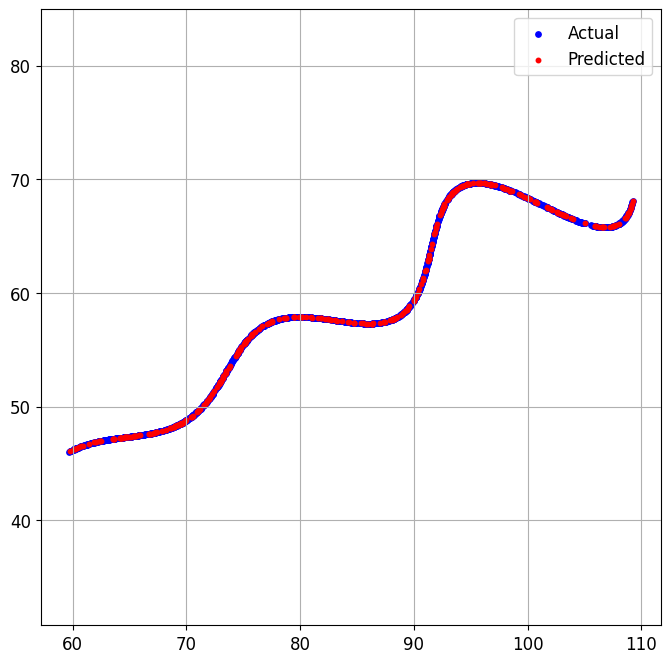

In [113]:
plt.figure(figsize=(8,8))

plt.scatter(
    actual_x,
    actual_y,
    label="Actual",
    s=15,
    color="blue"
)

plt.scatter(
    pred_x,
    pred_y,
    label="Predicted",
    linewidth=2,
    color="red",
    s=5
)

plt.legend()
plt.grid()
plt.axis("equal")
plt.show()

since we are integrating real data to calculate t , we have better way to estimate and also we have reduced much computation than before , since we take a real point and we use it to calculate prediction based on the t formula I derived . This helps us get good estimate of unknowns

![WhatsApp Image 2026-07-04 at 9.57.49 PM.jpeg](<attachment:WhatsApp Image 2026-07-04 at 9.57.49 PM.jpeg>)
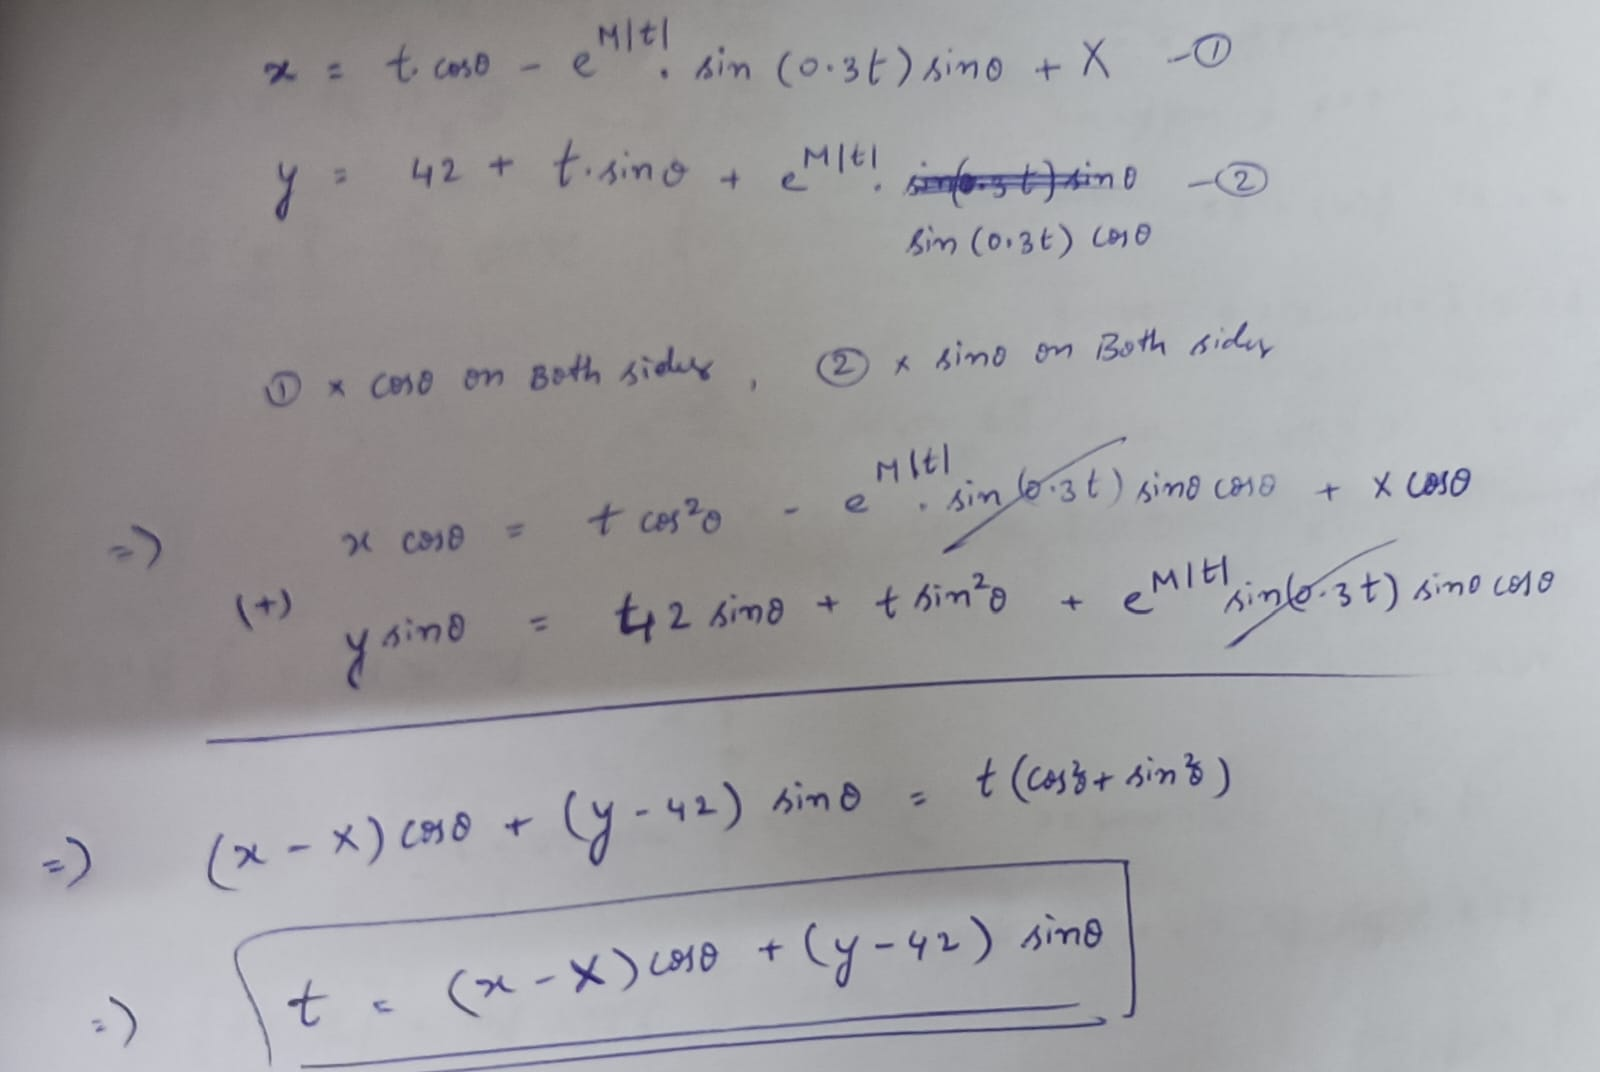

### Approach 3

After obtaining a strong solution using Differential Evolution, a final experiment was performed to investigate whether local optimization algorithms could further improve the estimated parameters.

Unlike Differential Evolution, which performs a global search over the parameter space, local optimization algorithms refine a solution by searching only within the neighborhood of an initial estimate.

Powell and Nelder–Mead were evaluated using the same objective function developed in Approach 2. Both algorithms started from a common initial parameter estimate and minimized the same L1 objective, allowing a fair comparison with the global optimization approach.

The objective of this experiment was not only to evaluate solution quality but also to compare optimization runtime and convergence behavior across different optimization strategies.

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

actual_x = df["x"].values
actual_y = df["y"].values
def objective(params):

    theta_deg, M, X = params

    theta = np.deg2rad(theta_deg)

    t = (
        (actual_x - X) * np.cos(theta)
        +
        (actual_y - 42) * np.sin(theta)
    )

    pred_x = (
        t*np.cos(theta)
        -
        np.exp(M*np.abs(t))*np.sin(0.3*t)*np.sin(theta)
        +
        X
    )

    pred_y = (
        42
        +
        t*np.sin(theta)
        +
        np.exp(M*np.abs(t))*np.sin(0.3*t)*np.cos(theta)
    )

    return np.sum(
        np.abs(pred_x-actual_x)
        +
        np.abs(pred_y-actual_y)
    )
initial_guess = [25,0.0,50]

bounds = [
    (0,50),
    (-0.05,0.05),
    (0,100)
]

optimizers = [
    "Powell",
    "Nelder-Mead"
]

results=[]

for method in optimizers:

    print(f"\nRunning {method}...")

    start=time.time()

    if method=="Powell":

        res=minimize(
            objective,
            initial_guess,
            method="Powell",
            bounds=bounds,
            options={
                "maxiter":1000
            }
        )

    else:

        res=minimize(
            objective,
            initial_guess,
            method="Nelder-Mead",
            options={
                "maxiter":1000
            }
        )

    end=time.time()

    theta,M,X=res.x

    results.append({

        "Method":method,
        "Theta":theta,
        "M":M,
        "X":X,
        "L1":res.fun,
        "Time (s)":end-start
    })

comparison=pd.DataFrame(results)

comparison.sort_values("L1")


Running Powell...

Running Nelder-Mead...


,Method,Theta,M,X,L1,Time (s)
0,Powell,29.999973,0.03,54.999998,0.005261,0.071366
1,Nelder-Mead,29.999973,0.03,54.999998,0.005298,0.015967


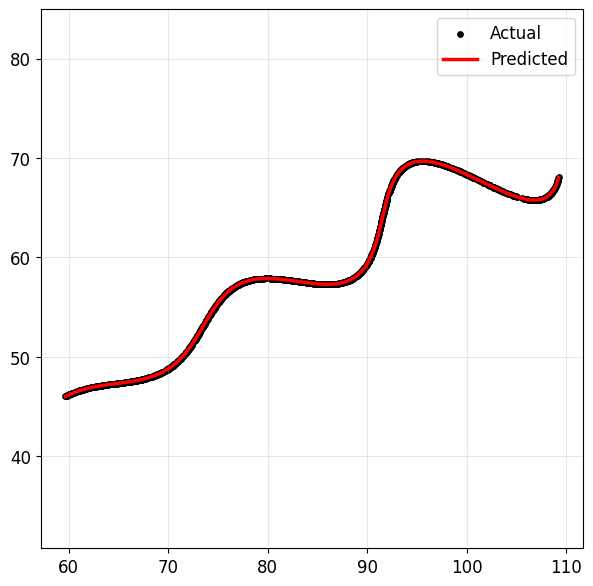

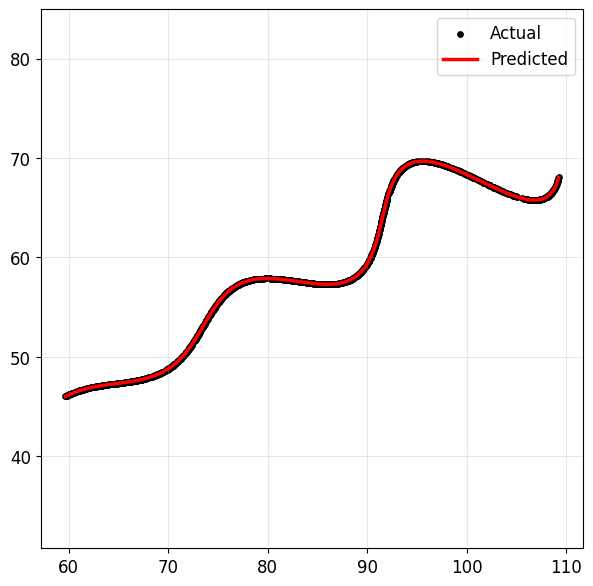

In [121]:
for row in results:

    theta=np.deg2rad(row["Theta"])

    M=row["M"]

    X=row["X"]

    t=(
        (actual_x-X)*np.cos(theta)
        +
        (actual_y-42)*np.sin(theta)
    )

    pred_x=(
        t*np.cos(theta)
        -
        np.exp(M*np.abs(t))*np.sin(0.3*t)*np.sin(theta)
        +
        X
    )

    pred_y=(
        42
        +
        t*np.sin(theta)
        +
        np.exp(M*np.abs(t))*np.sin(0.3*t)*np.cos(theta)
    )

    order = np.argsort(t)

    plt.figure(figsize=(7,7))

    plt.scatter(
        actual_x,
        actual_y,
        c="black",
        s=15,
        label="Actual"
    )

    plt.plot(
        pred_x[order],
        pred_y[order],
        color="red",
        linewidth=2.5,
        label="Predicted"
    )

    plt.axis("equal")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

In [122]:
results_dict = comparison.set_index("Method").to_dict("index")
results_dict["Powell"]["L1"]
results_dict["Powell"]["Time (s)"]

results_dict["Nelder-Mead"]["L1"]
results_dict["Nelder-Mead"]["Time (s)"]
final_results = pd.DataFrame({

    "Approach":[
        "Approach 1\n(DE + KDTree)",
        "Approach 2\n(Analytical t + DE)",
        "Approach 3\n(Powell)",
        "Approach 3\n(Nelder-Mead)"
    ],

    "L1":[
        approach1_l1,
        approach2_l1,
        results_dict["Powell"]["L1"],
        results_dict["Nelder-Mead"]["L1"]
    ],

    "Time (s)":[
        approach1_time,
        approach2_time,
        results_dict["Powell"]["Time (s)"],
        results_dict["Nelder-Mead"]["Time (s)"]
    ]

})

final_results = final_results.sort_values("L1")

display(final_results)

,Approach,L1,Time (s)
1,Approach 2\n(Analytical t + DE),0.004147,0.404988
2,Approach 3\n(Powell),0.005261,0.071366
3,Approach 3\n(Nelder-Mead),0.005298,0.015967
0,Approach 1\n(DE + KDTree),6.111363,5.789859


Among all the implemented approaches, the analytical formulation combined with Differential Evolution achieved the lowest L1 error while also reducing the computational complexity introduced by dense curve sampling and nearest-neighbor matching.

The local optimization methods successfully converged to feasible solutions; however, they consistently produced slightly higher L1 errors than Differential Evolution. This suggests that the optimization landscape contains multiple local minima, making a global optimization strategy more suitable for recovering the unknown parameters.

Overall, incorporating mathematical insight into the optimization problem proved more beneficial than simply changing the optimization algorithm, demonstrating that problem reformulation can significantly improve both efficiency and accuracy.